In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter


In [28]:
df = pd.read_csv('/content/CleanedData (2).csv')
display(df.head())

,URL,Product_id,BrandName,Category,Individual_category,category_by_Gender,Description,DiscountPrice,OriginalPrice,DiscountPercentage,SizeOption,SizeCount
0,https://www.myntra.com/jeans/roadster/roadster...,2296012,Roadster,Bottom wear,Jeans,Men,roadster men navy blue slim fit mid rise clean...,824.45,1499.0,45.0,"28, 30, 32, 34, 36",5
1,https://www.myntra.com/track-pants/locomotive/...,13780156,Locomotive,Bottom wear,Track-pants,Men,locomotive men black white solid slim fit trac...,517.05,1149.0,55.0,"S, M, L, XL",4
2,https://www.myntra.com/shirts/roadster/roadste...,11895958,Roadster,Topwear,Shirts,Men,roadster men navy white black geometric printe...,629.55,1399.0,55.0,"38, 40, 42, 44, 46, 48",6
3,https://www.myntra.com/shapewear/zivame/zivame...,4335679,Zivame,Lingerie & sleep wear,Shapewear,Women,zivame women black saree shapewear zi3023core0...,893.55,1295.0,31.0,"S, M, L, XL, XXL",5
4,https://www.myntra.com/tshirts/roadster/roadst...,11690882,Roadster,Western,Tshirts,Women,roadster women white solid v neck pure cotton ...,389.35,599.0,35.0,"XS, S, M, L, XL",5


### Univariate Analysis: Outlier Detection
We use boxplots to visualize the distribution of prices and identify potential outliers.

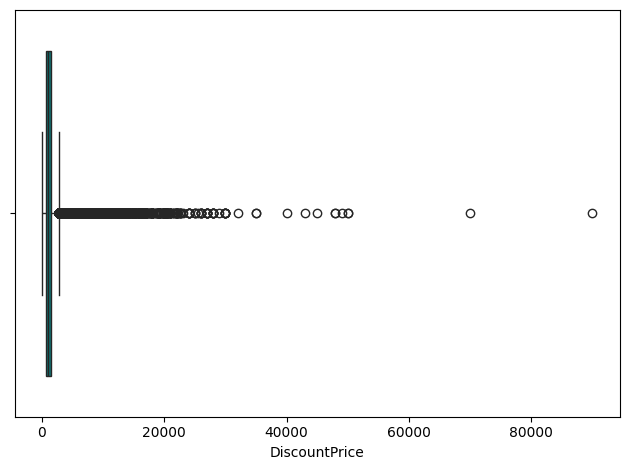

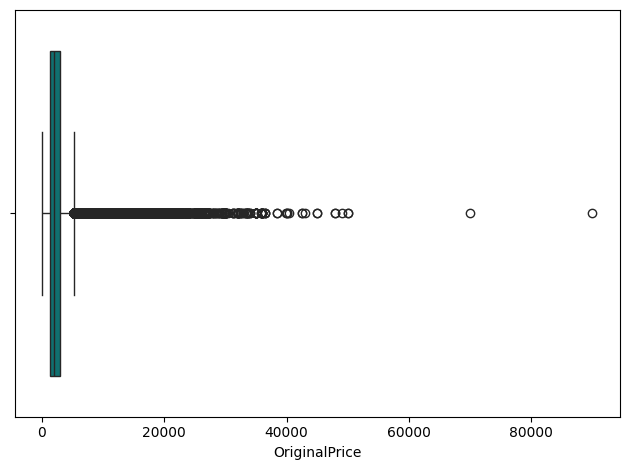

In [42]:
feature_list = ['DiscountPrice','OriginalPrice']
for n in feature_list:
    sns.boxplot(x = df[n], color='teal')
    plt.tight_layout()
    plt.show()

### Univariate Analysis: Price Distributions
These histograms show the frequency distribution of discount and original prices.

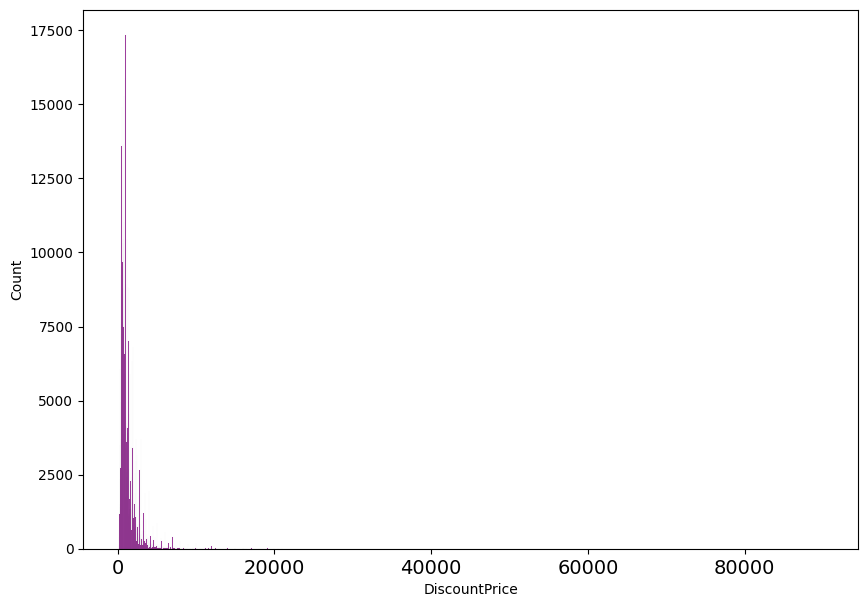

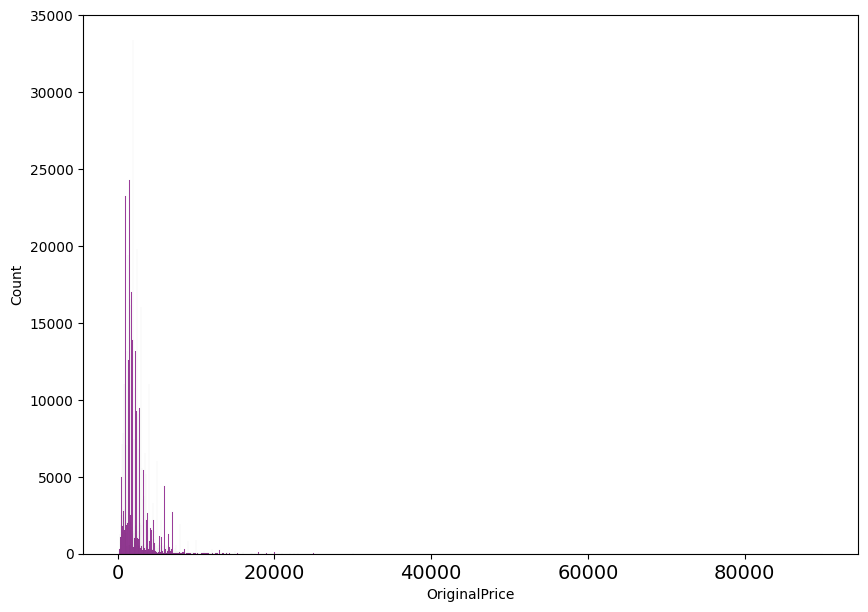

In [43]:
feature_list = ['DiscountPrice','OriginalPrice']

for i in feature_list:
    plt.figure(figsize=(10,7))
    sns.histplot(x=df[i], color='purple')
    plt.xticks(fontsize=14)
    plt.show()

### Bivariate Analysis: Price Density by Gender
Density plots help us compare how price distributions differ between gender categories.

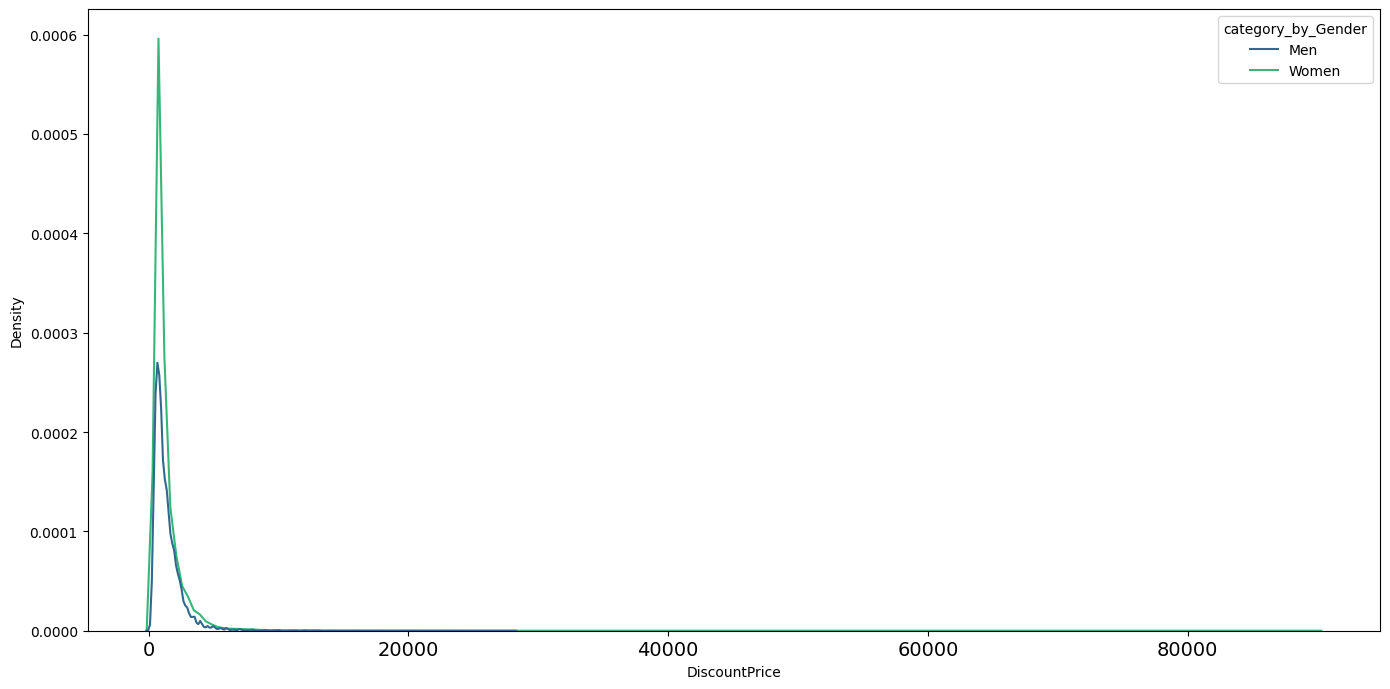

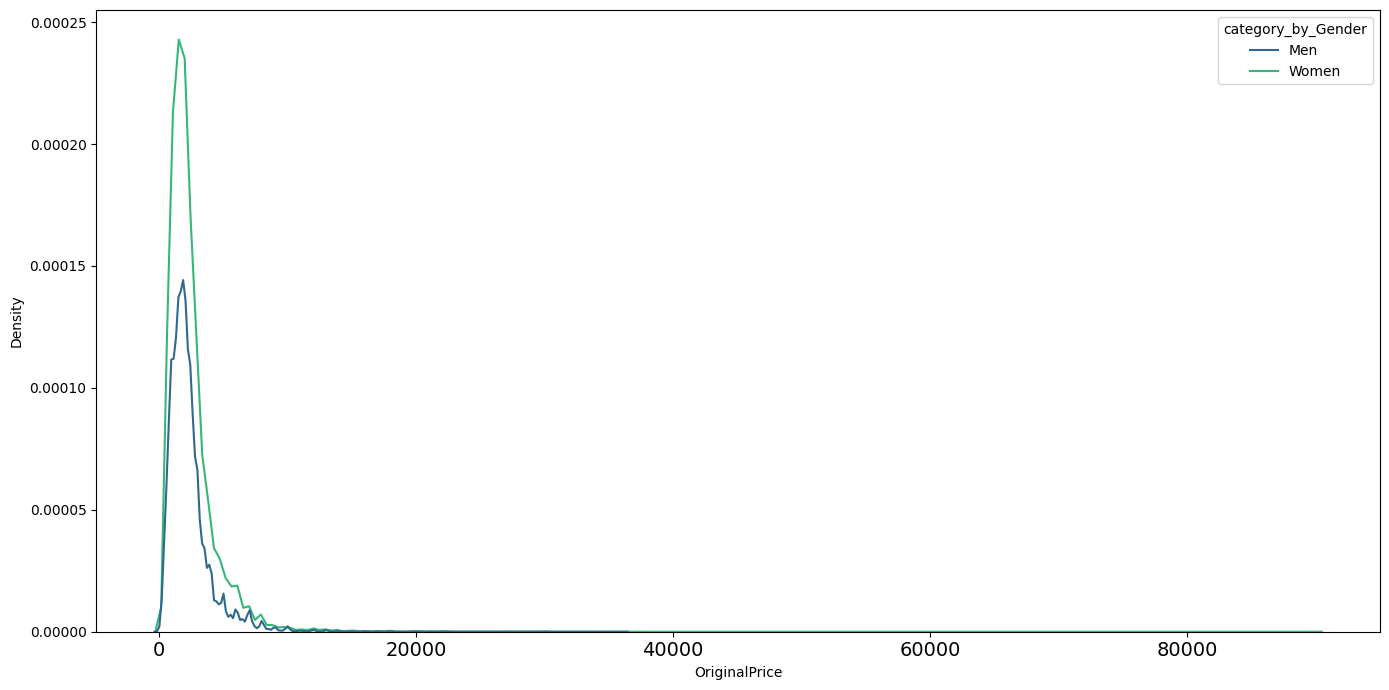

In [44]:
feature_list = ['DiscountPrice','OriginalPrice']
for i in feature_list:
    plt.figure(figsize=(14,7))
    sns.kdeplot(x=df[i], hue=df['category_by_Gender'], palette='viridis')
    plt.xticks(fontsize=14)
    plt.tight_layout()
    plt.show()

### Bivariate Analysis: Correlation between Prices
A regression plot to examine the relationship between Original Price and Discount Price.

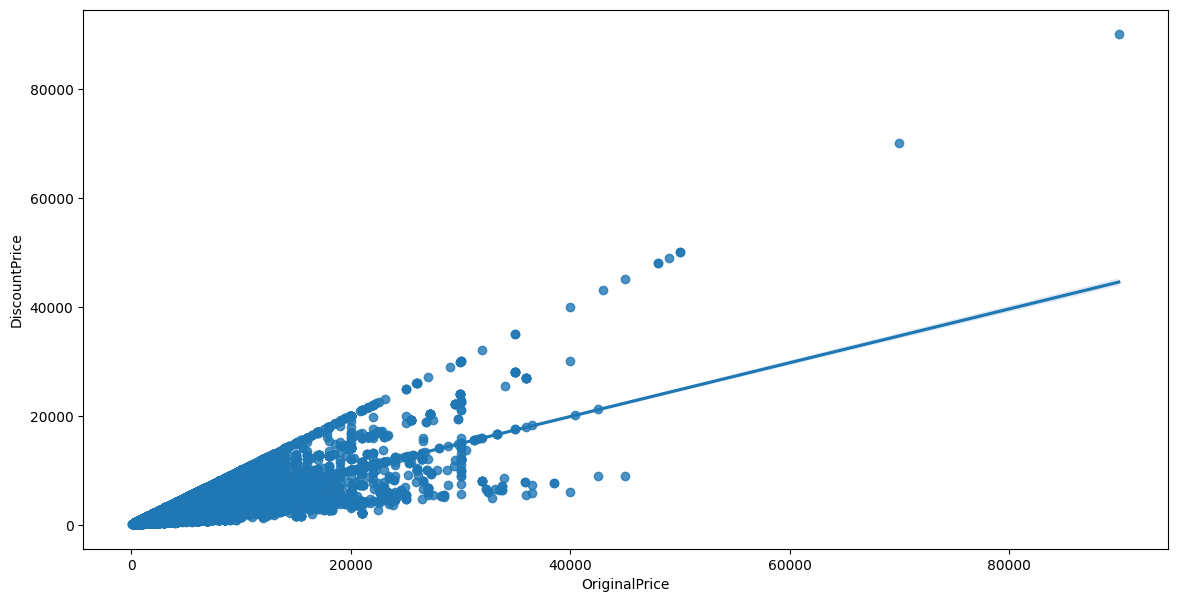

In [32]:
plt.figure(figsize=(14,7))
sns.regplot(x=df['OriginalPrice'], y=df['DiscountPrice'])
plt.show()

### Univariate Analysis: Gender Distribution
A pie chart showing the proportion of products across gender categories.

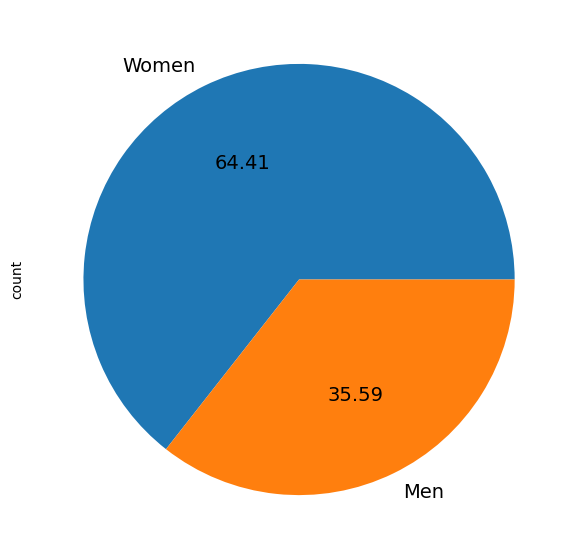

In [33]:
plt.figure(figsize=(14,7))
df['category_by_Gender'].value_counts().plot.pie(autopct='%.2f', textprops={'size':14})
plt.show()

### Multivariate Analysis: Categorical Features
Examining the top 10 occurrences for Brand, Discount Percentage, and Size options.

/tmp/ipykernel_11433/3075441421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='Spectral')
/tmp/ipykernel_11433/3075441421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='Spectral')
/tmp/ipykernel_11433/3075441421.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='Spectral')


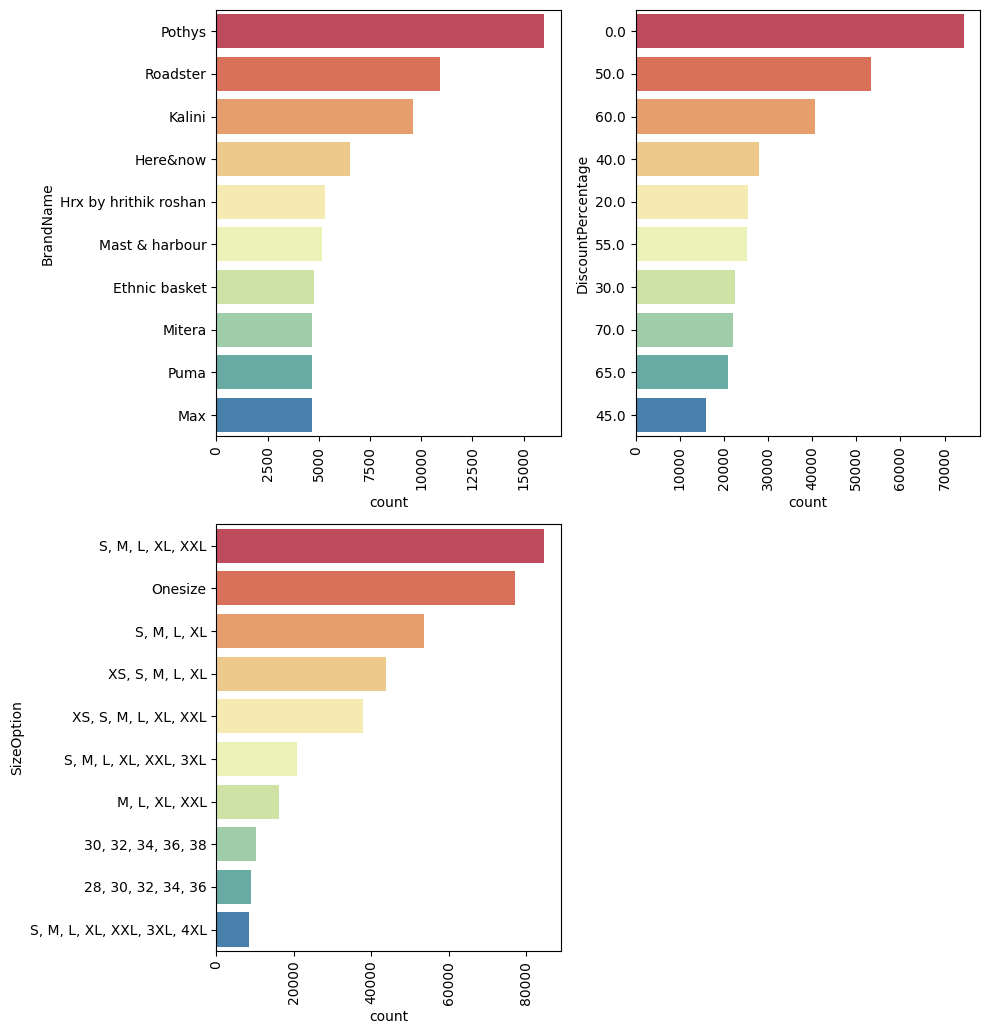

In [34]:
coluns = ['BrandName','DiscountPercentage', 'SizeOption']

plt.figure(figsize=(10,20))
for i, col in enumerate(coluns):
    axes = plt.subplot(4,2, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='Spectral')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11433/879840678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='viridis')
/tmp/ipykernel_11433/879840678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='viridis')
/tmp/ipykernel_11433/879840678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='viridis')


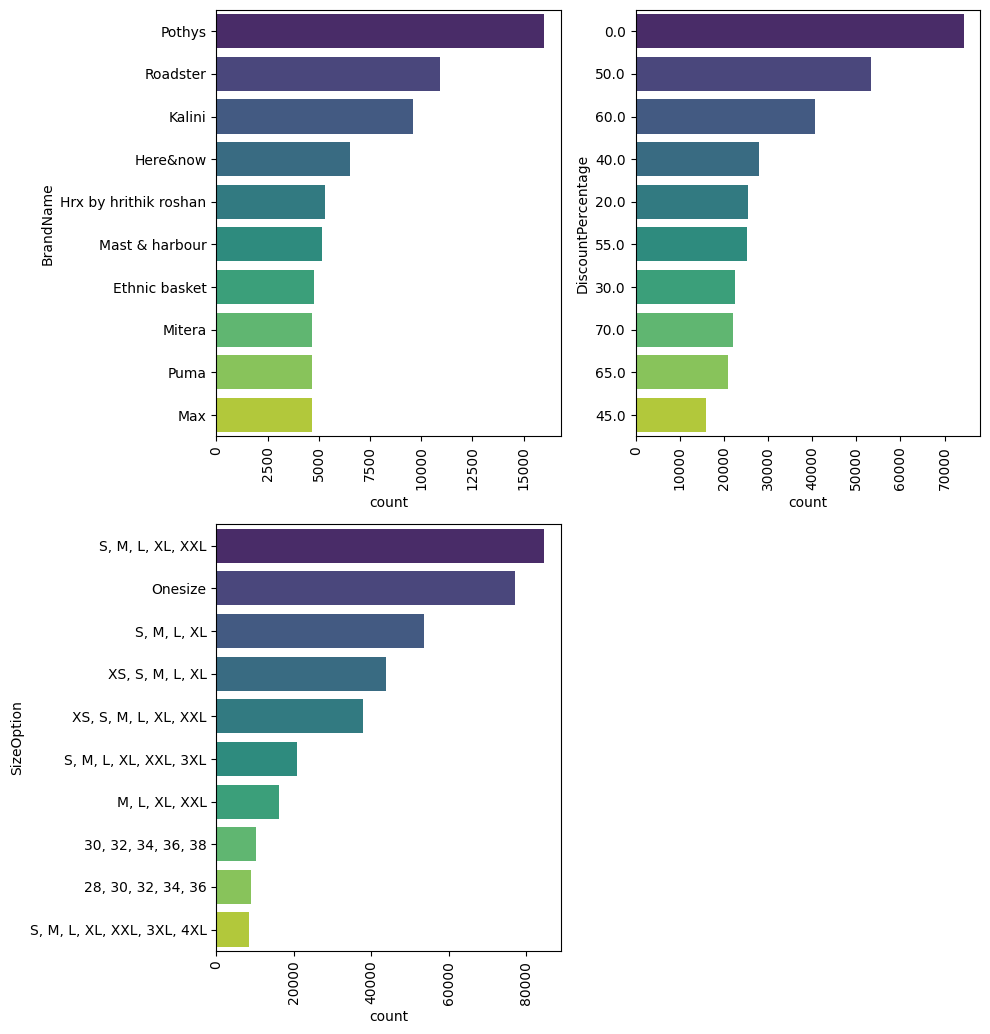

In [35]:
feature_list = ['BrandName','DiscountPercentage', 'SizeOption']

plt.figure(figsize=(10,20))
for i, col in enumerate(feature_list):
    axes = plt.subplot(4,2, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[0:10], palette='viridis')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

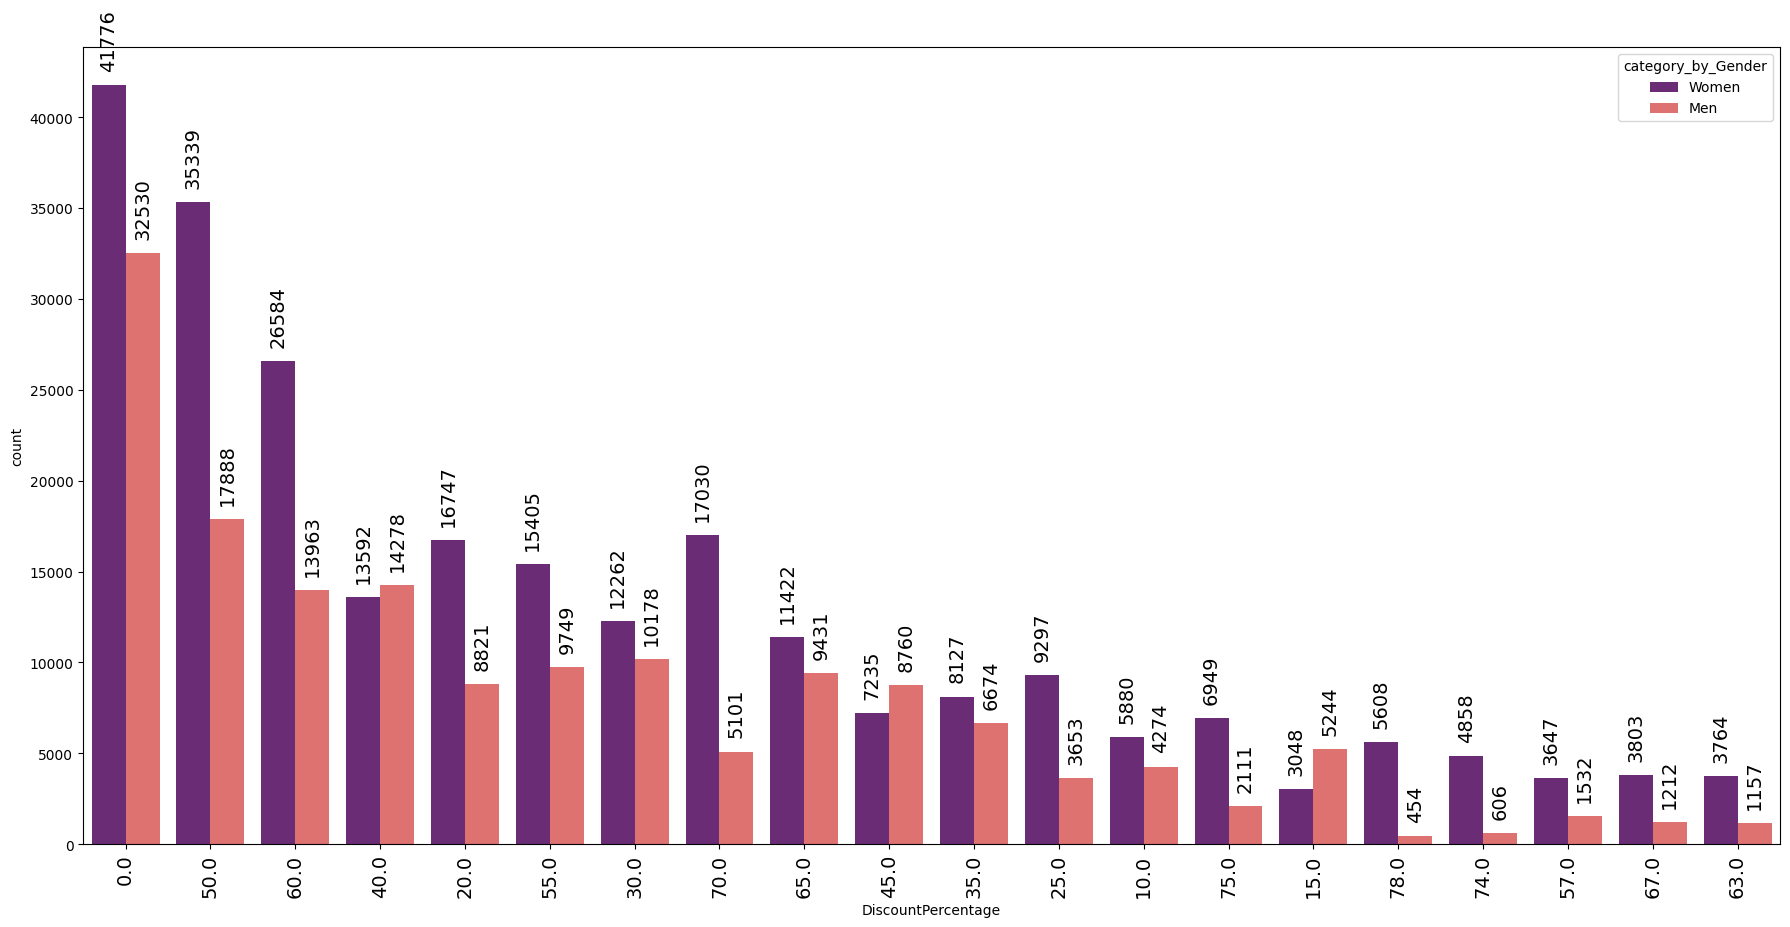

In [45]:
fig, ax = plt.subplots(figsize=(18,9))
sns.countplot(x=df['DiscountPercentage'], hue=df['category_by_Gender'],
              order=df['DiscountPercentage'].value_counts().index[0:20], palette='magma')
plt.xticks(rotation=90, fontsize=14)
plt.tight_layout()

for cont in ax.containers:
    ax.bar_label(cont, fontsize=14, rotation=90, padding=10)

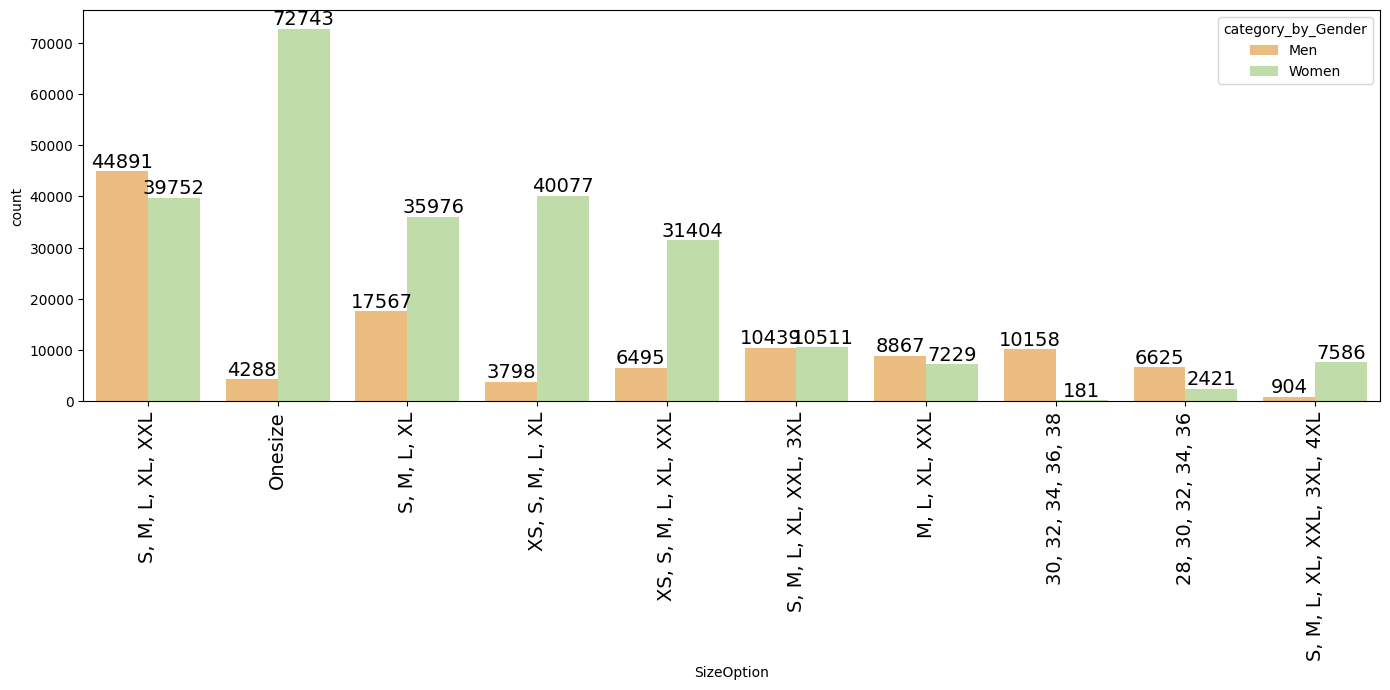

In [37]:
fig, ax = plt.subplots(figsize=(14,7))
sns.countplot(x=df['SizeOption'], hue=df['category_by_Gender'],order=df['SizeOption'].value_counts().index[0:10], palette='Spectral')
plt.xticks(rotation=90, fontsize=14)
plt.tight_layout()

for cont in ax.containers:
    ax.bar_label(cont, fontsize=14)

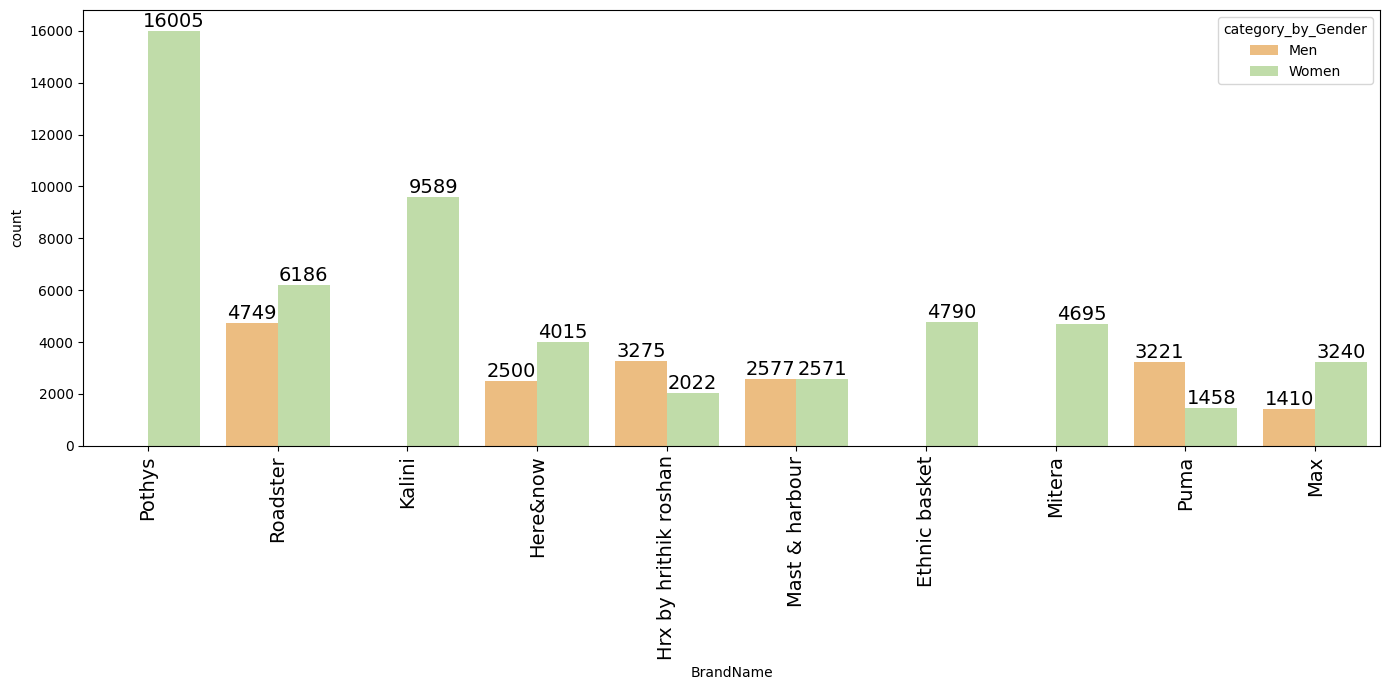

In [38]:
fig, ax = plt.subplots(figsize=(14,7))
sns.countplot(x=df['BrandName'], hue=df['category_by_Gender'],order=df['BrandName'].value_counts().index[0:10], palette='Spectral')
plt.xticks(rotation=90, fontsize=14)
plt.tight_layout()

for cont in ax.containers:
    ax.bar_label(cont, fontsize=14)

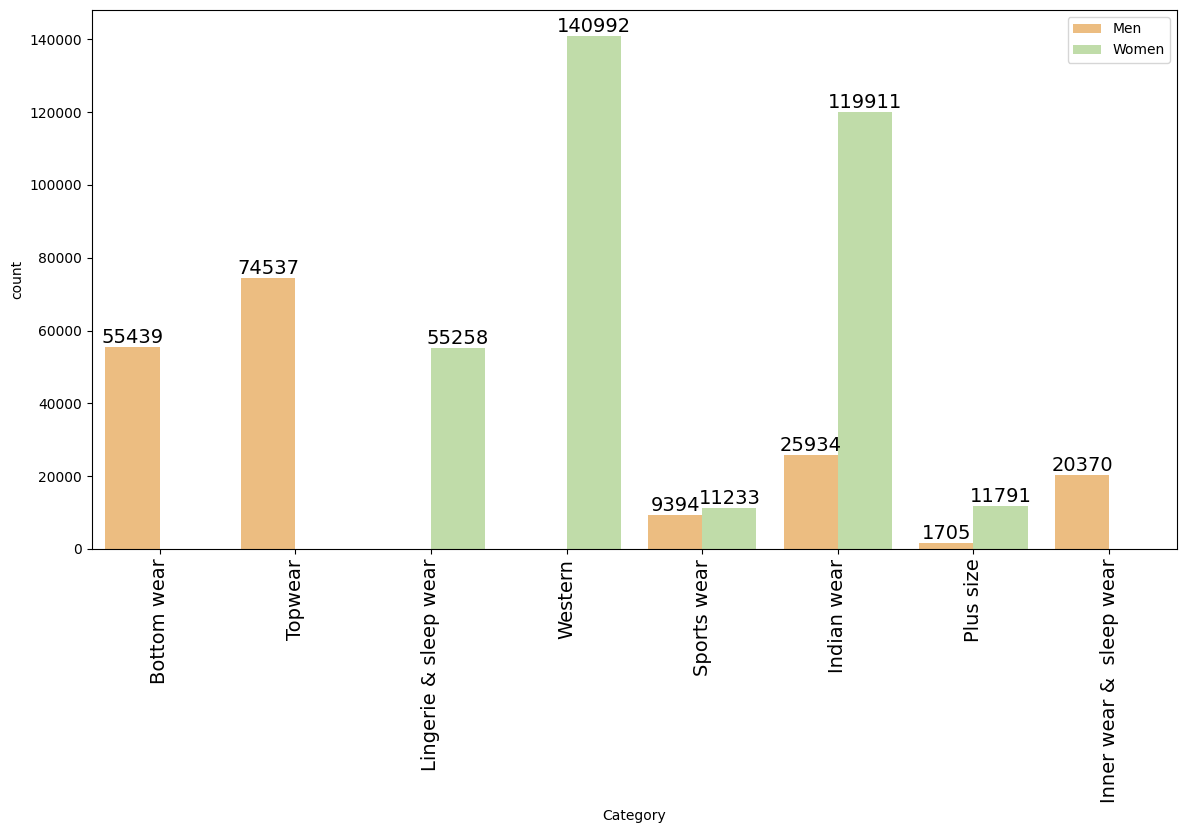

In [39]:
fig, ax = plt.subplots(figsize=(14,7))
sns.countplot(x=df['Category'], hue=df['category_by_Gender'], palette='Spectral')
plt.xticks(rotation=90, fontsize=14)
plt.legend(loc='upper right')
for cont in ax.containers:
    ax.bar_label(cont, fontsize=14)

### Additional EDA: Word Cloud and Categorical Distributions

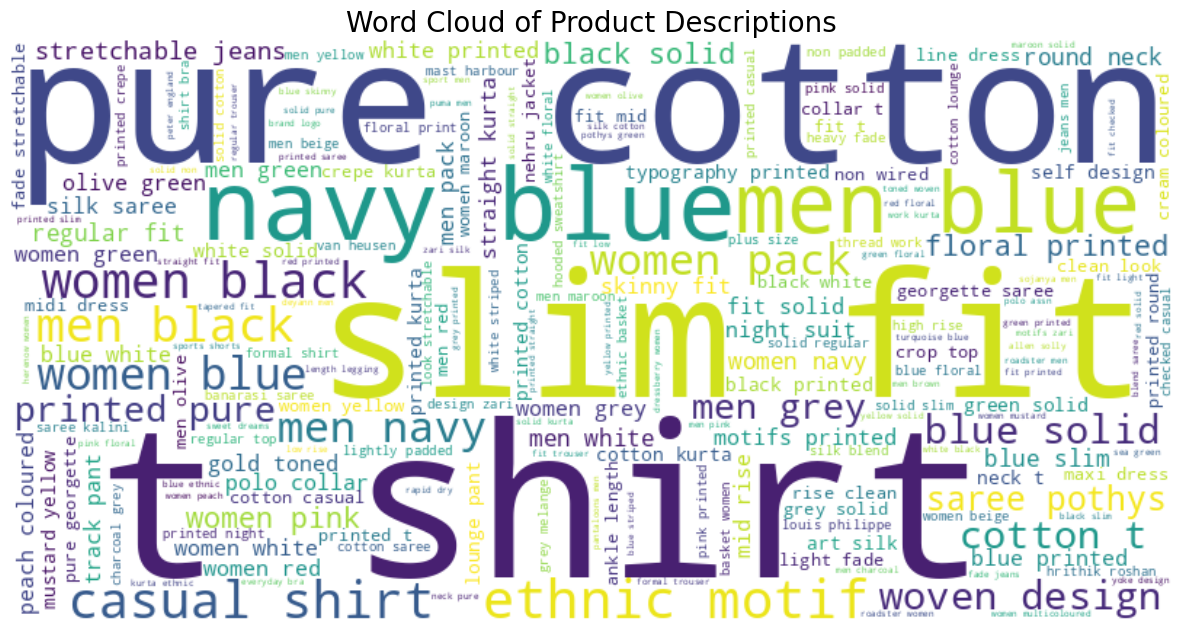

In [40]:
if 'Description' in df.columns:
    text = ' '.join(df['Description'].astype(str).tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(15, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Product Descriptions', fontsize=20)
    plt.show()
else:
    print("Column 'Description' not found for Word Cloud.")

/tmp/ipykernel_11433/1320228586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='DiscountPercentage', palette='Set3')


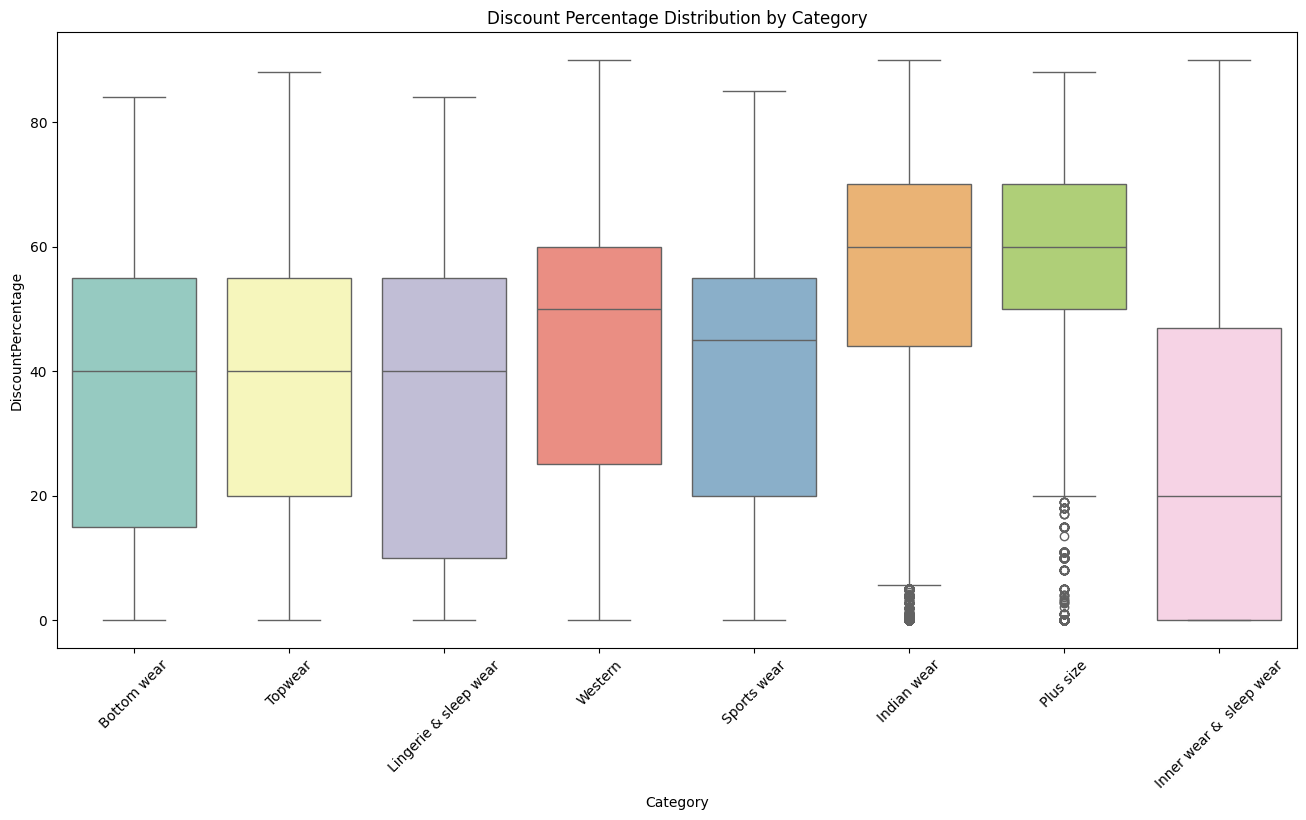

In [41]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='Category', y='DiscountPercentage', palette='Set3')
plt.xticks(rotation=45)
plt.title('Discount Percentage Distribution by Category')
plt.show()